# **ResNet-50 (Configuration 3)** 

This configuration builds on C2 by significantly increasing the regularization strength and adding Batch Normalization to the classifier head while retaining the same two-phase fine-tuning strategy.

**1. Model Architecture & Output**
*   **Classifier Head**: The classifier head is heavily regularized: `GAP -> Batch Normalization -> Dense(256) -> Dropout(0.6) -> Dense(1)`. 
    *   *Batch Normalization* stabilizes the regression output.
    *   *Dropout* is doubled to *0.6* for aggressive prevention of overfitting.
    *   *L2 Regularization (2e-4)* is doubled compared to C2.
*   **Output Formulation**: **Linear (ordinal regression)**.

**2. Data Pipeline**
*   **Preprocessing & Augmentation**: Identical to C2, utilizing robust **Data Augmentation** (rotation, shift, zoom, flip).
*   **Class Weights**: Set to **None**.

**3. Two-Phase Training Strategy**
The model uses **Mean Squared Error (MSE)** loss across two phases with Backbone BN layers **Frozen**:
*   **Phase 1 (Warm-up)**: Base layers frozen. Trained using **AdamW** (WD=2e-4) at a CosineDecay learning rate of **5e-4**. (Early Stopping Patience = 5).
*   **Phase 2 (Fine-tuning)**: The **top 30 layers** are unfrozen. Learning rate drops to **5e-5** (CosineDecay) using **AdamW** (WD=2e-4). (Early Stopping Patience = 5).

### Model Configuration

| Parameter | Configuration 3 |
| :--- | :--- |
| **Output Formulation** | Linear (ordinal regression) |
| **Loss Function** | Mean Squared Error (MSE) |
| **Preprocessing** | Data Augmentation (rotation, shift, zoom, flip) |
| **Phase 1 Optimizer** | AdamW (LR=5e-4 CosineDecay, WD=2e-4) |
| **Phase 2 Optimizer** | AdamW (LR=5e-5 CosineDecay, WD=2e-4) |
| **Unfrozen Layers (P2)** | Last 30 (BN Frozen) |
| **Class Weights** | None |
| **Classifier Head** | GAP → BN → Dense(256) → DO(0.6) → Dense(1) |
| **L2 Regularization** | 2e-4 (Dense layer) |
| **Early Stopping** | P1: Patience=5, P2: Patience=5 |


In [1]:
import sys
print(sys.executable)

/workspaces/fyp_experiment/.venv-4/bin/python


In [2]:
import os
import json
import timeit
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

I0000 00:00:1780498697.382565    2019 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as exc:
            print(f'Could not enable memory growth for {gpu}: {exc}')
    mixed_precision.set_global_policy('mixed_float16')

print('TF version:', tf.__version__)
print('GPUs:', gpus)
print('Mixed precision:', mixed_precision.global_policy())

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5050, compute capability 12.0
TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <Policy "mixed_float16">


W0000 00:00:1780498701.173256    2019 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Dataset Configuration

The notebook is wired to the balanced KOA dataset split used throughout the project.

In [4]:
def find_dataset_dir() -> Path:
    candidates = [
        Path('/workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis'),
        Path.cwd() / 'data' / 'knee_osteoarthritis',
        Path.cwd().resolve().parents[1] / 'data' / 'knee_osteoarthritis',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')

BASE_DIR = find_dataset_dir()
TRAIN_PATH = str(BASE_DIR / 'train_balanced')
VALID_PATH = str(BASE_DIR / 'val')
TEST_PATH = str(BASE_DIR / 'test')
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = len(CLASS_NAMES)
SEED = 12049

print('BASE_DIR:', BASE_DIR)
print('TRAIN_PATH:', TRAIN_PATH)
print('VALID_PATH:', VALID_PATH)
print('TEST_PATH:', TEST_PATH)
print('CLASS_NAMES:', CLASS_NAMES)

BASE_DIR: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis
TRAIN_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/train_balanced
VALID_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/val
TEST_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/test
CLASS_NAMES: ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']


## 2. Helpers

These helpers inspect the dataset and compute the evaluation outputs used later in the notebook.

In [5]:
def get_classes(data_path, classes, data):
    print(f'----{data}----')
    knee_severity = {}
    count = 0
    for i in range(len(classes)):
        imgs = os.listdir(os.path.join(data_path, str(i)))
        knee_severity[i] = imgs
        count += len(imgs)
    for k, v in knee_severity.items():
        print(f'Grade {k}-{classes[k]}: {len(v)} images, {round((len(v) * 100) / count, 2)}%')
    return knee_severity

def plot_classes(dict_classes, data_path, classes, data):
    for k, v in dict_classes.items():
        print(f'{data}-{classes[k]}')
        plt.figure(figsize=(10, 25))
        for i in range(5):
            img_path = os.path.join(data_path, str(k), v[i])
            img = tf.keras.preprocessing.image.load_img(img_path)
            plt.subplot(1, 5, 1 + i, xticks=[], yticks=[])
            plt.imshow(img)
            plt.title(f'Grade {k}')
        plt.show()

def compute_confusion_matrix(ytrue, ypred, class_names, model_name):
    pred_values = np.asarray(ypred).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    pred_labels = np.rint(pred_values).astype(int)
    cm = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    cmn = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f'Accuracy Score - {model_name}: {acc:.2f}')
    print(f'Balanced Accuracy Score - {model_name}: {bal_acc:.2f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
def get_plot_loss_acc(history_obj, model_name):
    history_data = history_obj.history if hasattr(history_obj, 'history') else history_obj
    metric_key = next((key for key in ('accuracy', 'ordinal_accuracy', 'mae') if key in history_data), None)
    val_metric_key = f'val_{metric_key}' if metric_key else None

    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(history_data['loss'])
    plt.plot(history_data['val_loss'])
    plt.title(f'{model_name} - Loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'valid'], loc='upper right')

    plt.subplot(2, 1, 2)
    if metric_key and val_metric_key in history_data:
        plt.plot(history_data[metric_key])
        plt.plot(history_data[val_metric_key])
        metric_label = metric_key.replace('_', ' ').title()
    else:
        metric_label = 'Metric'
        plt.text(0.5, 0.5, f'No accuracy-style metric found. Available keys: {list(history_data.keys())}', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title(f'{model_name} - {metric_label}')
    plt.ylabel(metric_label.lower())
    plt.xlabel('epoch')
    plt.legend(['train', 'valid'], loc='lower right')
    plt.tight_layout()
def ordinal_predictions_to_labels(predictions, class_names):
    pred_values = np.asarray(predictions).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    pred_labels = np.rint(pred_values).astype(int)
    return pred_values, pred_labels
def ordinal_score_matrix(predictions, class_names):
    pred_values = np.asarray(predictions).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    class_positions = np.arange(len(class_names), dtype=np.float32)
    scores = 1.0 / (1.0 + np.abs(pred_values[:, None] - class_positions[None, :]))
    scores = scores / np.sum(scores, axis=1, keepdims=True)
    return scores
@tf.keras.utils.register_keras_serializable()
def ordinal_accuracy(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    y_pred = tf.clip_by_value(tf.round(y_pred), 0.0, float(NUM_CLASSES - 1))
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32))
ordinal_accuracy.__name__ = 'accuracy'

def compute_confusion_matrix(ytrue, ypred, class_names, model_name):
    _, pred_labels = ordinal_predictions_to_labels(ypred, class_names)
    cmatrix = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    cmn = cmatrix.astype(float) / cmatrix.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def compute_confusion_matrix_counts(ytrue, ypred, class_names, model_name):
    _, pred_labels = ordinal_predictions_to_labels(ypred, class_names)
    cmatrix = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmatrix, annot=True, fmt='d', cmap='YlOrRd', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def get_evaluate(data, name, model):
    score_model = model.evaluate(data, verbose=1, return_dict=True)
    print(f"{name} loss: {score_model['loss']:.2f}")
    if 'mae' in score_model:
        print(f"{name} mae: {score_model['mae']:.2f}")
    if 'accuracy' in score_model:
        print(f"{name} accuracy: {score_model['accuracy']:.2f}")

def get_predict(data, model):
    return model.predict(data)

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f'Accuracy Score - {model_name}: {acc:.2f}')
    print(f'Balanced Accuracy Score - {model_name}: {bal_acc:.2f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

def compute_comprehensive_metrics(y_true, y_pred_probs, y_pred_labels, class_names, model_name):
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import mean_absolute_error

    print('=' * 80)
    print(f'COMPREHENSIVE EVALUATION - {model_name}')
    print('=' * 80)

    acc = accuracy_score(y_true, y_pred_labels)
    bal_acc = balanced_accuracy_score(y_true, y_pred_labels)
    mae = mean_absolute_error(y_true, np.asarray(y_pred_probs).reshape(-1))
    print(f'\nOVERALL ACCURACY:')
    print(f'   Accuracy: {acc:.4f}')
    print(f'   Balanced Accuracy: {bal_acc:.4f}')
    print(f'   MAE: {mae:.4f}')
    print(f'\nDETAILED CLASSIFICATION REPORT:')
    print(classification_report(y_true, y_pred_labels, target_names=class_names, digits=4))

    try:
        y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
        roc_scores = ordinal_score_matrix(y_pred_probs, class_names)
        roc_auc_macro = roc_auc_score(y_true_bin, roc_scores, multi_class='ovr', average='macro')
        roc_auc_weighted = roc_auc_score(y_true_bin, roc_scores, multi_class='ovr', average='weighted')
        print(f'\nROC AUC SCORES:')
        print(f'   ROC AUC (Macro): {roc_auc_macro:.4f}')
        print(f'   ROC AUC (Weighted): {roc_auc_weighted:.4f}')
    except Exception as exc:
        print(f'\nROC AUC calculation note: {str(exc)}')

def plot_roc_curves(y_true, y_pred_probs, class_names, model_name):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc

    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    score_matrix = ordinal_score_matrix(y_pred_probs, class_names)
    plt.figure(figsize=(12, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], score_matrix[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_f1_scores_per_class(y_true, y_pred_labels, class_names, model_name):
    from sklearn.metrics import f1_score

    f1_scores = []
    for i in range(len(class_names)):
        f1 = f1_score(y_true, y_pred_labels, labels=[i], average='weighted', zero_division=0)
        f1_scores.append(f1)

    colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
    for bar, score in zip(bars, f1_scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2., height, f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
    plt.xlabel('Osteoarthritis Grade', fontsize=12, fontweight='bold')
    plt.title(f'F1 Score Distribution - {model_name}', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.1])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Data Loading

ResNet-50 will use RGB inputs and native ImageNet preprocessing.

In [6]:
train_data = get_classes(TRAIN_PATH, CLASS_NAMES, 'train_balanced')
valid_data = get_classes(VALID_PATH, CLASS_NAMES, 'Valid')
test_data = get_classes(TEST_PATH, CLASS_NAMES, 'Test')

datagen = tf.keras.preprocessing.image.ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)
train_generator = datagen.flow_from_directory(TRAIN_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=True)
valid_generator = datagen.flow_from_directory(VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)

print('Using sparse integer labels for ordinal regression.')

----train_balanced----
Grade 0-Healthy: 2246 images, 20.01%
Grade 1-Doubtful: 2245 images, 20.0%
Grade 2-Minimal: 2245 images, 20.0%
Grade 3-Moderate: 2245 images, 20.0%
Grade 4-Severe: 2245 images, 20.0%
----Valid----
Grade 0-Healthy: 328 images, 39.71%
Grade 1-Doubtful: 153 images, 18.52%
Grade 2-Minimal: 212 images, 25.67%
Grade 3-Moderate: 106 images, 12.83%
Grade 4-Severe: 27 images, 3.27%
----Test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%
Found 11226 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Using sparse integer labels for ordinal regression.


## 4. Model Configuration

### Training Parameters
Define all hyperparameters and paths for the ResNet50 model. These settings have been optimized for balanced accuracy across all osteoarthritis severity grades.

In [ ]:
model_name = 'ResNet50_c3'
phase1_epochs = 20
max_epochs = 50
phase2_epochs = max_epochs - phase1_epochs
fine_tune_layers = 30
weight_decay = 2e-4

checkpoint = ModelCheckpoint(
    save_model_ft, monitor='val_loss', save_best_only=True, mode='min', verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
csv_logger_phase1 = CSVLogger('train_history.csv', append=False)

phase1_steps = max(len(train_generator), 1) * phase1_epochs
phase2_steps = max(len(train_generator), 1) * phase2_epochs
phase1_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-4,
    decay_steps=phase1_steps,
    alpha=0.1,
)
phase2_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=phase2_steps,
    alpha=0.1,
)


## 5. Model Architecture

### Building the ResNet50 Model
We use transfer learning by loading a pre-trained ResNet50 model on ImageNet weights. The base model is augmented with:
- Global average pooling to reduce spatial dimensions
- Dropout layer (0.2) for regularization
- Dense output layer (5 units) for the 5 osteoarthritis classes

In [ ]:
base_model = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(2e-4))(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(1, activation='linear', dtype='float32')(x)
model_ft = models.Model(inputs, outputs, name='ResNet50_c3')
model_ft.summary()

W0000 00:00:1780498701.623864    2019 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780498702.143082    2019 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5263 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


Model: "ResNet50_c2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 2048)              8192      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               

## 6. Training Setup

Use this cell to add callbacks, compile the model, and run the frozen-backbone warmup followed by fine-tuning.

In [8]:
model_dir = Path('models')
model_dir.mkdir(exist_ok=True)
save_model_ft = str(model_dir / 'best_model.keras')
print('Model will be saved to:', save_model_ft)

Model will be saved to: models/best_model.keras


## 7. Data Generators and Class Weights

This section creates the train, validation, and test generators using ResNet-50 preprocessing and computes class weights for the imbalanced target labels.

In [9]:
def build_generators(train_path, valid_path, test_path, img_size, batch_size):
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
        rotation_range=5,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest',
    )
    eval_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    )

    train_generator = train_datagen.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=True,
    )
    valid_generator = eval_datagen.flow_from_directory(
        valid_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=False,
    )
    test_generator = eval_datagen.flow_from_directory(
        test_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=False,
    )

    return train_generator, valid_generator, test_generator

train_generator, valid_generator, test_generator = build_generators(
    TRAIN_PATH, VALID_PATH, TEST_PATH, IMG_SIZE, BATCH_SIZE
)

print('Generators built with sparse labels.')

Found 11226 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Generators built with sparse labels.


## 8. Training and Fine-Tuning

The first phase trains the classifier head with the ResNet-50 backbone frozen. The second phase unfreezes the top ResNet blocks to fine-tune the feature extractor and reduce overfitting.

In [ ]:

model_ft.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=phase1_lr, weight_decay=weight_decay),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae'), ordinal_accuracy],
)

start_phase1 = timeit.default_timer()
history_phase1 = model_ft.fit(
    train_generator,
    epochs=phase1_epochs,
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, csv_logger_phase1],
    verbose=1,
)
stop_phase1 = timeit.default_timer()

base_model.trainable = True
for layer in base_model.layers[:-fine_tune_layers]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

csv_logger_phase2 = CSVLogger('train_history.csv', append=True)

model_ft.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=phase2_lr, weight_decay=weight_decay),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae'), ordinal_accuracy],
)

start_phase2 = timeit.default_timer()
history_phase2 = model_ft.fit(
    train_generator,
    epochs=max_epochs,
    initial_epoch=phase1_epochs,
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, csv_logger_phase2],
    verbose=1,
)
stop_phase2 = timeit.default_timer()

from types import SimpleNamespace

def merge_histories(*histories):
    merged = {'loss': [], 'mae': [], 'ordinal_accuracy': [], 'val_loss': [], 'val_mae': [], 'val_ordinal_accuracy': []}
    for history in histories:
        for key in merged:
            merged[key].extend(history.history.get(key, []))
    return SimpleNamespace(history=merged)

merged_history = merge_histories(history_phase1, history_phase2)

print(f'Phase 1 training time: {stop_phase1 - start_phase1:.2f} seconds')
print(f'Phase 2 training time: {stop_phase2 - start_phase2:.2f} seconds')
print(f'Total training time: {stop_phase2 - start_phase1:.2f} seconds')
print(f'Best model checkpoint: {save_model_ft}')

Epoch 1/20


I0000 00:00:1780498707.103930    2019 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780498731.052612    2547 cuda_dnn.cc:461] Loaded cuDNN version 90701
I0000 00:00:1780498752.346590    2543 service.cc:153] XLA service 0x7688bc02eec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780498752.346666    2543 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.1)
I0000 00:00:1780498752.372913    2543 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780498752.496764    2543 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


702/702 [==============================] - ETA: 0s - loss: 3.2802 - mae: 1.3829 - accuracy: 0.3171
Epoch 1: val_loss improved from inf to 1.35245, saving model to models/best_model.keras
702/702 [==============================] - 160s 162ms/step - loss: 3.2802 - mae: 1.3829 - accuracy: 0.3171 - val_loss: 1.3524 - val_mae: 0.8919 - val_accuracy: 0.4062
Epoch 2/20
702/702 [==============================] - ETA: 0s - loss: 1.2671 - mae: 0.8733 - accuracy: 0.3783
Epoch 2: val_loss improved from 1.35245 to 1.04707, saving model to models/best_model.keras
702/702 [==============================] - 106s 152ms/step - loss: 1.2671 - mae: 0.8733 - accuracy: 0.3783 - val_loss: 1.0471 - val_mae: 0.7888 - val_accuracy: 0.3870
Epoch 3/20
692/702 [============================>.] - ETA: 1s - loss: 1.0231 - mae: 0.7841 - accuracy: 0.3956
Epoch 3: val_loss did not improve from 1.04707
702/702 [==============================] - 101s 144ms/step - loss: 1.0200 - mae: 0.7827 - accuracy: 0.3960 - val_loss: 1

In [12]:
history_df = pd.concat([pd.DataFrame(history_phase1.history), pd.DataFrame(history_phase2.history)], ignore_index=True, sort=False)
history_df.to_csv('train_history.csv', index=False)

def to_json_serializable(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {key: to_json_serializable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_json_serializable(item) for item in value]
    return value

with open('train_history.json', 'w', encoding='utf-8') as f:
    json.dump({
        'phase1': to_json_serializable(history_phase1.history),
        'phase2': to_json_serializable(history_phase2.history),
    }, f, indent=2)

print('Saved train_history.csv and train_history.json')

Saved train_history.csv and train_history.json


### Training History Visualization
Visualize training and validation curves to assess model convergence and detect overfitting.

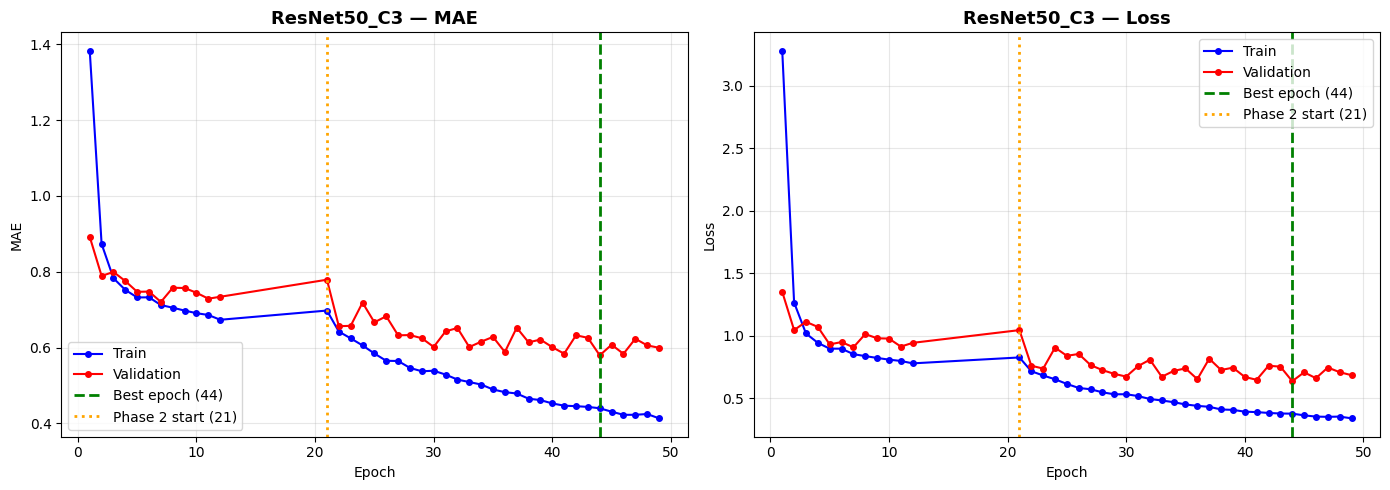

Total epochs: 41 (Phase 1: 12, Phase 2: 29)
Best epoch: 44 (from training logs)
Best val_loss: 0.6383
Early stopping at epoch: 49


In [ ]:
# ── Training History Visualization — ResNet50_C3 (MAE + Loss) ────────────────
import json
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path.cwd().resolve()
report_dir = output_dir / 'reports'
MODEL_NAME = "ResNet50_C3"

with open(report_dir / 'train_history.json', 'r', encoding='utf-8') as f:
    raw_history = json.load(f)

# Merge phases
history = {}
for key in raw_history['phase1']:
    history[key] = raw_history['phase1'][key] + raw_history['phase2'][key]

phase1_len = len(raw_history['phase1']['loss'])  # 12
phase2_len = len(raw_history['phase2']['loss'])  # 29
phase2_start_keras = 21  # initial_epoch=20, so phase 2 starts at epoch 21 (1-indexed)

# Reconstruct actual epoch numbers (1-12, then 21-49)
epoch_labels = list(range(1, phase1_len + 1)) + list(range(phase2_start_keras, phase2_start_keras + phase2_len))

# Best epoch = lowest val_loss (what ModelCheckpoint saved)
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MAE
ax1.plot(epoch_labels, history['mae'], 'b-o', markersize=4, label='Train')
ax1.plot(epoch_labels, history['val_mae'], 'r-o', markersize=4, label='Validation')
ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax1.axvline(x=phase2_start_keras, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start_keras})')
ax1.set_title(f'{MODEL_NAME} — MAE', fontsize=13, fontweight='bold')
ax1.set_ylabel('MAE')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epoch_labels, history['loss'], 'b-o', markersize=4, label='Train')
ax2.plot(epoch_labels, history['val_loss'], 'r-o', markersize=4, label='Validation')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax2.axvline(x=phase2_start_keras, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start_keras})')
ax2.set_title(f'{MODEL_NAME} — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total epochs: {len(history["loss"])} (Phase 1: {phase1_len}, Phase 2: {phase2_len})')
print(f'Best epoch: {best_epoch} (from training logs)')
print(f'Best val_loss: {min(history["val_loss"]):.4f}')
print(f'Early stopping at epoch: {epoch_labels[-1]}')


In [13]:
model_ft.save(save_model_ft)
print(f'Model saved to {save_model_ft}')

Model saved to models/best_model.keras


## 9. Validation Metrics

Evaluate the model on the validation split and inspect the class-wise errors.

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# RESNET50_C3 — FULL STANDALONE EVALUATION (Validation + Test)
# Metrics from CSV, plots from model predictions
# ══════════════════════════════════════════════════════════════════════════════
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (precision_recall_fscore_support,
                             roc_curve, auc, confusion_matrix)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Shared utils ─────────────────────────────────────────────────────────────
_KOA_ROOT = Path.cwd().resolve()
while _KOA_ROOT.name != 'knee_osteoarthritis' and _KOA_ROOT != _KOA_ROOT.parent:
    _KOA_ROOT = _KOA_ROOT.parent
if str(_KOA_ROOT) not in sys.path:
    sys.path.insert(0, str(_KOA_ROOT))

import importlib, utils.evaluation
importlib.reload(utils.evaluation)
from utils.evaluation import (
    continuous_to_ordinal_scores,
    threshold_predictions,
)

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "ResNet50_C3"
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 16

output_dir = Path.cwd().resolve()
model_dir = output_dir / 'models'
report_dir = output_dir / 'reports'
best_model_path = model_dir / 'best_model.keras'

# ── Optimized thresholds from training ───────────────────────────────────────
optimized_thresholds = np.array([0.5287116765975952, 1.55914306640625, 2.37512469291687, 3.5217185020446777], dtype=np.float32)

# ── Dataset paths ────────────────────────────────────────────────────────────
def find_dataset_dir():
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        for suffix in [('data', 'knee_osteoarthritis'), ('ml_workflow', 'data', 'knee_osteoarthritis'), ('Final_year_project', 'ml_workflow', 'data', 'knee_osteoarthritis')]:
            candidate = root.joinpath(*suffix)
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')

BASE_DIR = find_dataset_dir()
VALID_PATH = BASE_DIR / 'val'
TEST_PATH = BASE_DIR / 'test'

# ── Data generators ──────────────────────────────────────────────────────────
datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)
valid_generator = datagen.flow_from_directory(VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)

# ── Custom metrics (needed to load the model) ────────────────────────────────
@tf.keras.utils.register_keras_serializable(package='koa')
class OrdinalAccuracy(tf.keras.metrics.Metric):
    def __init__(self, num_classes=5, name='ordinal_accuracy', **kwargs):
        super(OrdinalAccuracy, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.counter = self.add_weight(name='counter', initializer='zeros', dtype=tf.float32)
        self.total = self.add_weight(name='total', initializer='zeros', dtype=tf.float32)
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(tf.round(tf.clip_by_value(tf.reshape(y_pred, [-1]), 0, self.num_classes - 1)), tf.int32)
        self.counter.assign_add(tf.cast(tf.reduce_sum(tf.cast(tf.equal(y_true, y_pred), tf.float32)), tf.float32))
        self.total.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))
    def result(self):
        return self.counter / (self.total + tf.keras.backend.epsilon())
    def reset_state(self):
        self.counter.assign(0.0)
        self.total.assign(0.0)
    def get_config(self):
        config = super().get_config()
        config.update({'num_classes': self.num_classes})
        return config

@tf.keras.utils.register_keras_serializable(package='Custom')
def ordinal_accuracy(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(tf.reshape(y_pred, [-1]), 0.0, 4.0)), tf.int32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32))

# ── Display function (reads from CSV) ────────────────────────────────────────
def display_metrics_from_csv(csv_row, model_name, split_name):
    sep = '=' * 72
    sep2 = '-' * 72
    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<44} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<44} {csv_row["Accuracy"]:>10.4f}')
    print(f'  {"Balanced Accuracy":<44} {csv_row["Balanced Accuracy"]:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<44} {csv_row["MAE"]:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<44} {csv_row["Macro ROC AUC"]:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<44} {csv_row["Quadratic Weighted Kappa"]:>10.4f}')
    print(f'{sep}\n')

# ── Plot functions ───────────────────────────────────────────────────────────
def plot_roc(y_true, score_matrix, class_names, title):
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    plt.figure(figsize=(10, 7))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], score_matrix[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

def plot_f1(y_true, pred_labels, class_names, title):
    _, _, f1, _ = precision_recall_fscore_support(y_true, pred_labels, labels=range(len(class_names)), zero_division=0)
    plt.figure(figsize=(8, 5))
    bars = plt.bar(class_names, f1, color='steelblue', edgecolor='black')
    for bar, val in zip(bars, f1):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=10)
    plt.ylim(0, 1.0)
    plt.ylabel('F1 Score')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_cm(y_true, pred_labels, class_names, title, normalize=False):
    cm = confusion_matrix(y_true, pred_labels, labels=range(len(class_names)))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(7, 6))
    fmt = '.2f' if normalize else 'd'
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# ── Display function (metrics from CSV + per-class from predictions) ─────────
def display_full_metrics(csv_row, y_true, pred_labels, model_name, split_name):
    sep = '=' * 72
    sep2 = '-' * 72

    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<44} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<44} {csv_row["Accuracy"]:>10.4f}')
    print(f'  {"Balanced Accuracy":<44} {csv_row["Balanced Accuracy"]:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<44} {csv_row["MAE"]:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<44} {csv_row["Macro ROC AUC"]:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<44} {csv_row["Quadratic Weighted Kappa"]:>10.4f}')
    print(f'{sep}')

    # Per-class breakdown from predictions
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, pred_labels, labels=range(NUM_CLASSES), zero_division=0)

    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    for i, cname in enumerate(CLASS_NAMES):
        print(f'  {cname:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {int(sup[i]):>10}')
    print(f'  {sep2}')

    accuracy = csv_row["Accuracy"]
    total_support = int(np.sum(sup))
    print(f'  {"accuracy":<14} {"":>10} {"":>10} {accuracy:>10.4f} {total_support:>10}')
    print(f'  {"macro avg":<14} {np.mean(prec):>10.4f} {np.mean(rec):>10.4f} {np.mean(f1):>10.4f} {total_support:>10}')
    print(f'  {"weighted avg":<14} {np.average(prec, weights=sup):>10.4f} {np.average(rec, weights=sup):>10.4f} {np.average(f1, weights=sup):>10.4f} {total_support:>10}')
    print(f'  {sep2}\n')


# ── Load model ───────────────────────────────────────────────────────────────
best_model = tf.keras.models.load_model(str(best_model_path), safe_mode=False)
print('Loaded best model from:', best_model_path)

# ── Read CSV files ───────────────────────────────────────────────────────────
val_csv = pd.read_csv(report_dir / 'validation_comprehensive_metrics_matrix.csv')
test_csv = pd.read_csv(report_dir / 'test_comprehensive_metrics_matrix.csv')


Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Loaded best model from: /workspaces/fyp_experiment/Final_year_project/ml_workflow/training/knee_osteoarthritis/ResNet_50/ResNet_50_C3/models/best_model.keras


In [12]:
# ── Display function (metrics from CSV + per-class from predictions) ─────────
def display_full_metrics(csv_row, y_true, pred_labels, model_name, split_name):
    sep = '=' * 72
    sep2 = '-' * 72

    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<44} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<44} {csv_row["Accuracy"]:>10.4f}')
    print(f'  {"Balanced Accuracy":<44} {csv_row["Balanced Accuracy"]:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<44} {csv_row["MAE"]:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<44} {csv_row["Macro ROC AUC"]:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<44} {csv_row["Quadratic Weighted Kappa"]:>10.4f}')
    print(f'{sep}')

    # Per-class breakdown from predictions
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, pred_labels, labels=range(NUM_CLASSES), zero_division=0)

    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    for i, cname in enumerate(CLASS_NAMES):
        print(f'  {cname:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {int(sup[i]):>10}')
    print(f'  {sep2}')

    accuracy = csv_row["Accuracy"]
    total_support = int(np.sum(sup))
    print(f'  {"accuracy":<14} {"":>10} {"":>10} {accuracy:>10.4f} {total_support:>10}')
    print(f'  {"macro avg":<14} {np.mean(prec):>10.4f} {np.mean(rec):>10.4f} {np.mean(f1):>10.4f} {total_support:>10}')
    print(f'  {"weighted avg":<14} {np.average(prec, weights=sup):>10.4f} {np.average(rec, weights=sup):>10.4f} {np.average(f1, weights=sup):>10.4f} {total_support:>10}')
    print(f'  {sep2}\n')


52/52 [==============================] - 7s 112ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : ResNet50_C3
  Split : Validation
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5327
  Balanced Accuracy                                0.5451
  Mean Absolute Error (MAE)                        0.5629
  Macro ROC AUC (ordinal matrix)                   0.8394
  Quadratic Weighted Kappa (QWK)                   0.7450

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.6803     0.6616     0.6708        328
  Doubtful           0.2659     0.4379     0.3309        153
  Minimal            0.6341     0.3679     0.4657        212
  Moderate         

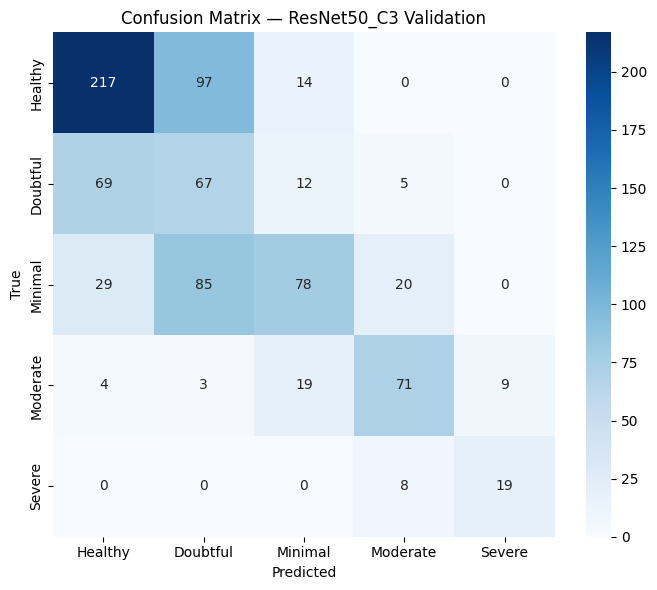

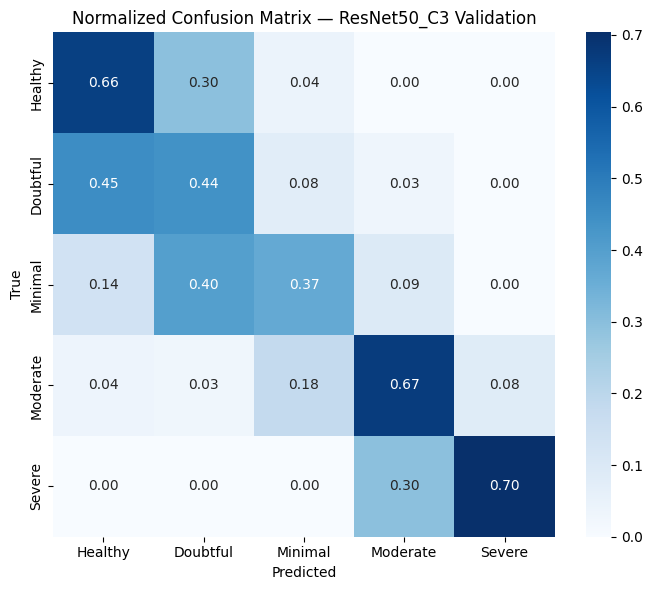

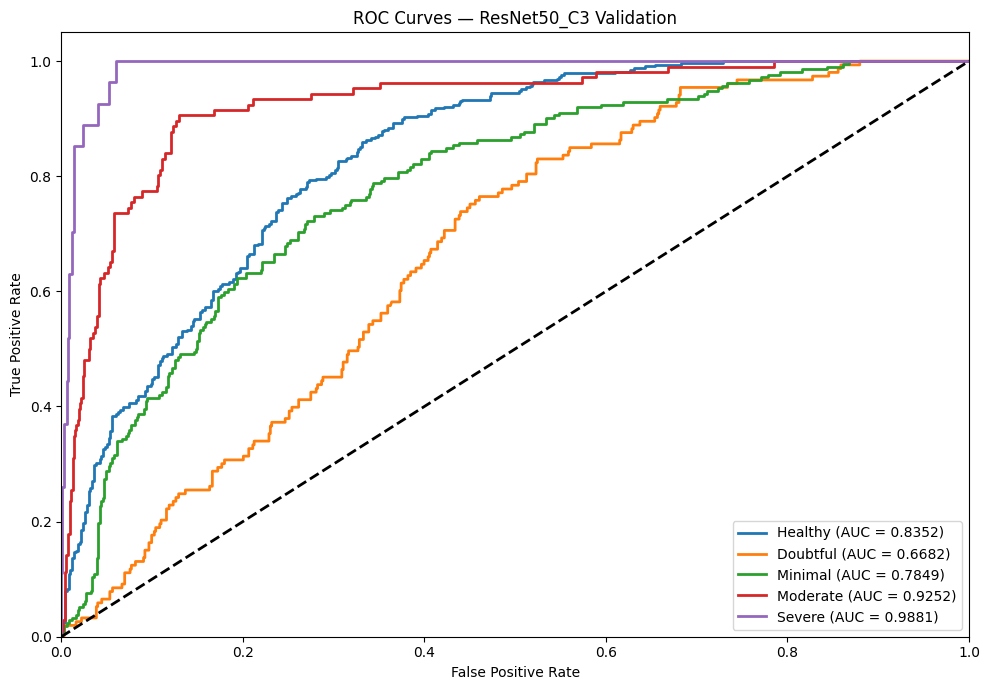

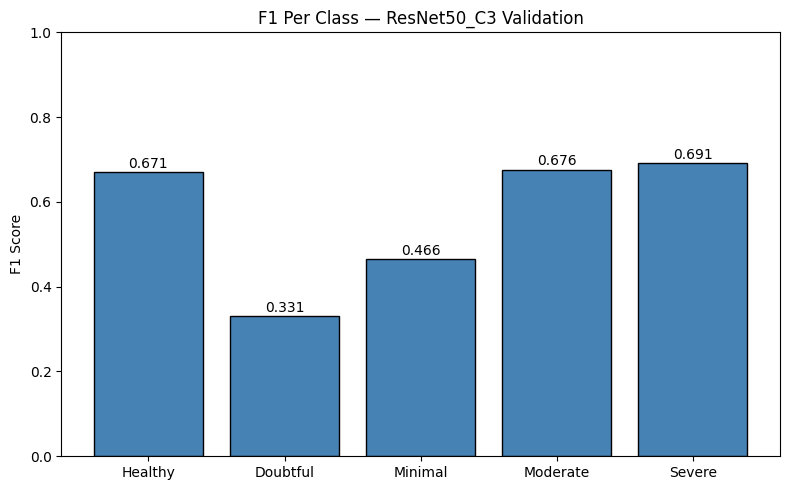

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION
# ══════════════════════════════════════════════════════════════════════════════
valid_generator.reset()
val_continuous = best_model.predict(valid_generator, verbose=1).reshape(-1)
val_true = valid_generator.labels

_, val_pred_labels = threshold_predictions(val_continuous, optimized_thresholds)
val_probs = continuous_to_ordinal_scores(val_continuous)

display_full_metrics(val_csv.iloc[0], val_true, val_pred_labels, MODEL_NAME, 'Validation')
plot_cm(val_true, val_pred_labels, CLASS_NAMES, f'Confusion Matrix — {MODEL_NAME} Validation', normalize=False)
plot_cm(val_true, val_pred_labels, CLASS_NAMES, f'Normalized Confusion Matrix — {MODEL_NAME} Validation', normalize=True)
plot_roc(val_true, val_probs, CLASS_NAMES, f'ROC Curves — {MODEL_NAME} Validation')
plot_f1(val_true, val_pred_labels, CLASS_NAMES, f'F1 Per Class — {MODEL_NAME} Validation')



## 10. Test Set Evaluation

Reload the best saved model and run the final evaluation on the independent test split.

104/104 [==============================] - 9s 90ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : ResNet50_C3
  Split : Test
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5876
  Balanced Accuracy                                0.5834
  Mean Absolute Error (MAE)                        0.5166
  Macro ROC AUC (ordinal matrix)                   0.8634
  Quadratic Weighted Kappa (QWK)                   0.7896

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.7364     0.7606     0.7483        639
  Doubtful           0.2988     0.4865     0.3702        296
  Minimal            0.6250     0.3691     0.4641        447
  Moderate           0.6

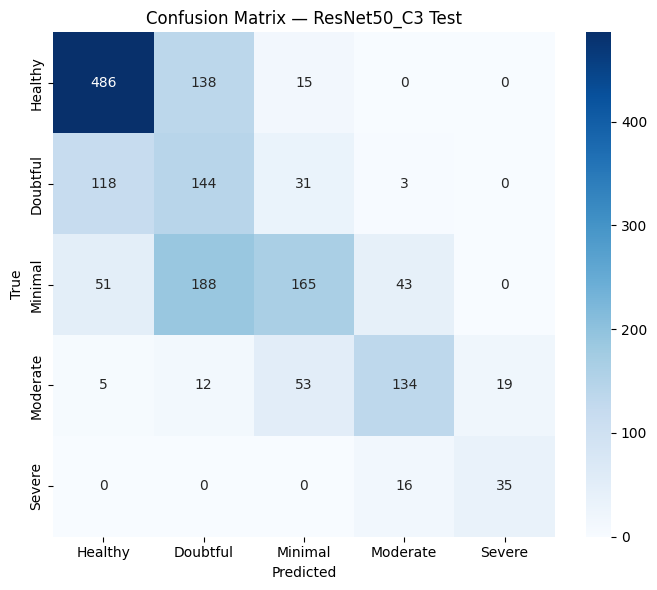

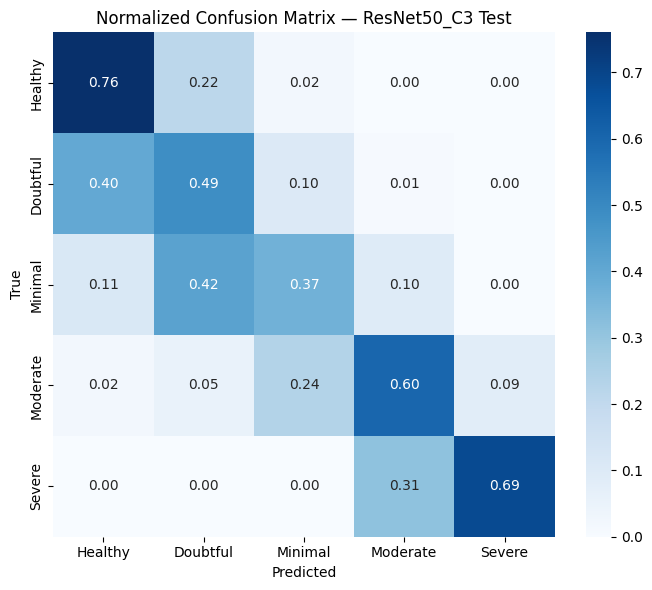

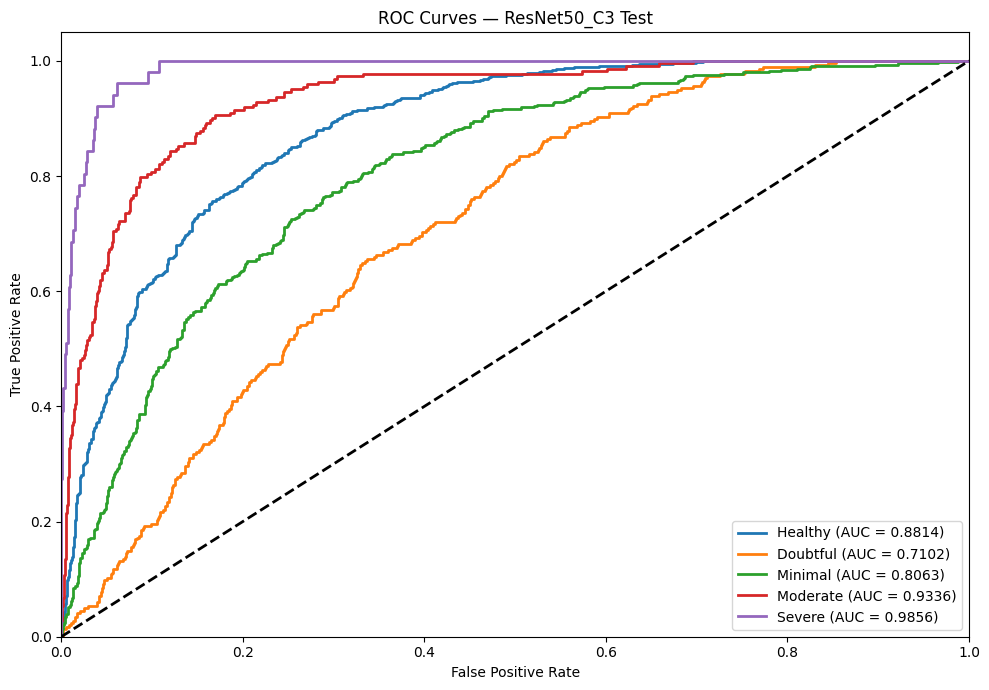

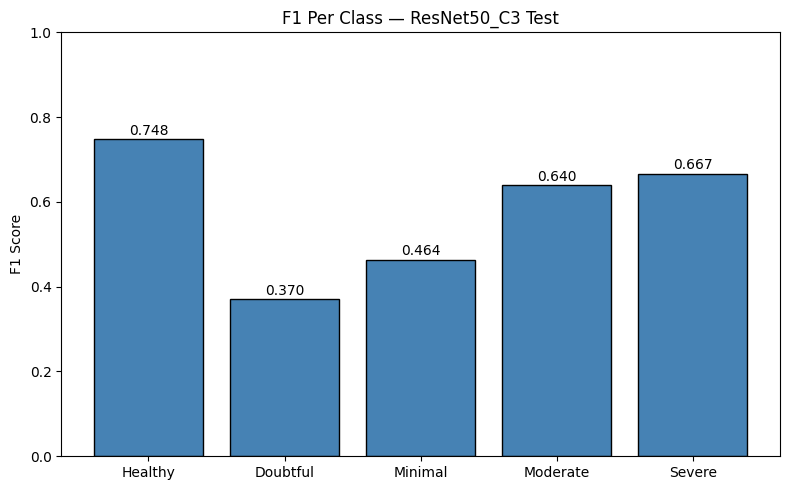

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# TEST
# ══════════════════════════════════════════════════════════════════════════════
test_generator.reset()
test_continuous = best_model.predict(test_generator, verbose=1).reshape(-1)
test_true = test_generator.labels

_, test_pred_labels = threshold_predictions(test_continuous, optimized_thresholds)
test_probs = continuous_to_ordinal_scores(test_continuous)

display_full_metrics(test_csv.iloc[0], test_true, test_pred_labels, MODEL_NAME, 'Test')
plot_cm(test_true, test_pred_labels, CLASS_NAMES, f'Confusion Matrix — {MODEL_NAME} Test', normalize=False)
plot_cm(test_true, test_pred_labels, CLASS_NAMES, f'Normalized Confusion Matrix — {MODEL_NAME} Test', normalize=True)
plot_roc(test_true, test_probs, CLASS_NAMES, f'ROC Curves — {MODEL_NAME} Test')
plot_f1(test_true, test_pred_labels, CLASS_NAMES, f'F1 Per Class — {MODEL_NAME} Test')



In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE eval_report.txt (run AFTER validation and test cells)
# Uses the SAME val_pred_labels and test_pred_labels from the cells above
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             mean_absolute_error, cohen_kappa_score,
                             classification_report)

# Verify these match the displayed output
print(f'Sanity check — Val accuracy: {accuracy_score(val_true, val_pred_labels):.4f}')
print(f'Sanity check — Test accuracy: {accuracy_score(test_true, test_pred_labels):.4f}')

v_acc = accuracy_score(val_true, val_pred_labels)
v_bal_acc = balanced_accuracy_score(val_true, val_pred_labels)
v_mae = mean_absolute_error(val_true, val_pred_labels)
v_qwk = cohen_kappa_score(val_true, val_pred_labels, weights='quadratic')
v_report = classification_report(val_true, val_pred_labels, target_names=CLASS_NAMES)

test_acc = accuracy_score(test_true, test_pred_labels)
test_bal_acc = balanced_accuracy_score(test_true, test_pred_labels)
test_mae = mean_absolute_error(test_true, test_pred_labels)
test_qwk = cohen_kappa_score(test_true, test_pred_labels, weights='quadratic')
test_report = classification_report(test_true, test_pred_labels, target_names=CLASS_NAMES)

eval_report = (
    f'Test Accuracy: {test_acc:.4f}\n'
    f'Balanced Accuracy: {test_bal_acc:.4f}\n'
    f'MAE: {test_mae:.4f}\n'
    f'QWK: {test_qwk:.4f}\n\n'
    f'Validation classification report:\n{v_report}\n'
    f'Test classification report:\n{test_report}'
)

with open(report_dir / 'eval_report.txt', 'w', encoding='utf-8') as f:
    f.write(eval_report)

print('\nSaved updated eval_report.txt')
print(f'Validation | Accuracy={v_acc:.4f}  Balanced={v_bal_acc:.4f}  MAE={v_mae:.4f}  QWK={v_qwk:.4f}')
print(f'Test       | Accuracy={test_acc:.4f}  Balanced={test_bal_acc:.4f}  MAE={test_mae:.4f}  QWK={test_qwk:.4f}')



Sanity check — Val accuracy: 0.5472
Sanity check — Test accuracy: 0.5821

Saved updated eval_report.txt
Validation | Accuracy=0.5472  Balanced=0.5682  MAE=0.5242  QWK=0.7544
Test       | Accuracy=0.5821  Balanced=0.5807  MAE=0.4728  QWK=0.7859


## 12. Model Interpretability & Visualization

Grad-CAM helps verify whether the model focuses on clinically relevant regions instead of irrelevant background patterns.

In [22]:
def make_gradcam_heatmap(grad_model, img_array, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = 0 if preds.shape[-1] == 1 else tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * alpha + img
    return tf.keras.preprocessing.image.array_to_img(superimposed_img)

----test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%
Test data - Healthy


/tmp/ipykernel_2019/2451040415.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap('jet')


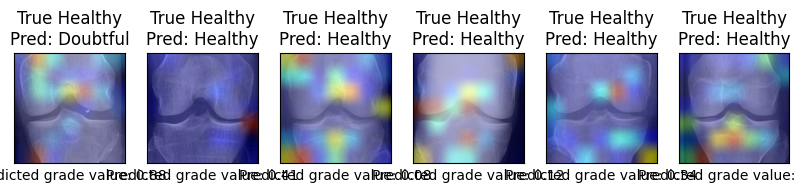

Test data - Doubtful


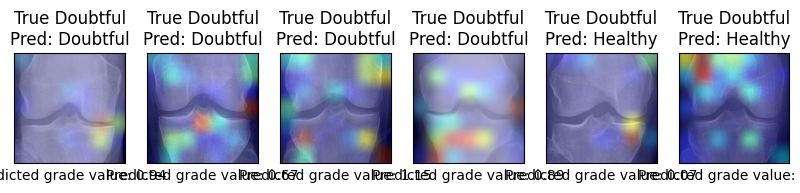

Test data - Minimal


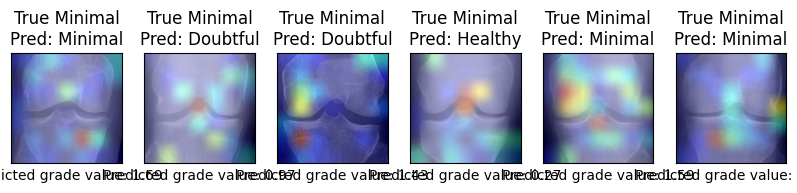

Test data - Moderate


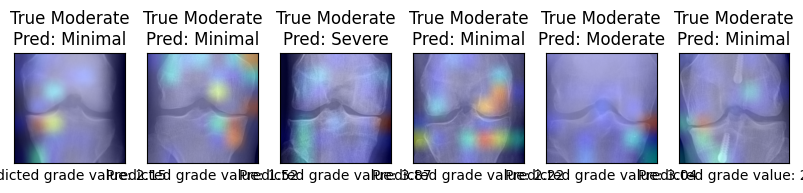

Test data - Severe


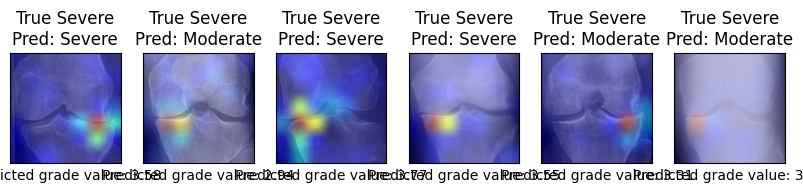

In [23]:
tests_data = get_classes(TEST_PATH, CLASS_NAMES, 'test')
resnet_backbone = resnet_model.get_layer('resnet50')
conv_output = resnet_backbone.get_layer('conv5_block3_out').output
x = resnet_model.layers[2](conv_output)
x = resnet_model.layers[3](x, training=False)
x = resnet_model.layers[4](x)
x = resnet_model.layers[5](x, training=False)
preds = resnet_model.layers[6](x)
grad_model = tf.keras.models.Model(inputs=resnet_backbone.input, outputs=[conv_output, preds])
gradcam_dir = 'gradcam_outputs'
os.makedirs(gradcam_dir, exist_ok=True)

for k, v in tests_data.items():
    print(f'Test data - {CLASS_NAMES[k]}')
    plt.figure(figsize=(10, 28))
    for i in range(6):
        img_path = os.path.join(TEST_PATH, str(k), v[i])
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img.copy(), axis=0)
        img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
        y_pred = resnet_model.predict(img_array, verbose=0)[0]
        heatmap = make_gradcam_heatmap(grad_model, img_array)
        image = save_and_display_gradcam(img, heatmap)
        image.save(os.path.join(gradcam_dir, f'{CLASS_NAMES[k]}_{i + 1}.png'))
        plt.subplot(1, 6, i + 1, xticks=[], yticks=[])
        plt.imshow(image)
        _, gradcam_pred_label = ordinal_predictions_to_labels(y_pred, CLASS_NAMES)
        plt.title(f'True {CLASS_NAMES[k]}\nPred: {CLASS_NAMES[gradcam_pred_label[0]]}')
        plt.xlabel(f'Predicted grade value: {float(np.asarray(y_pred).reshape(-1)[0]):.2f}')
    plt.show()